# Example

A problem from the test: calculate 

```{math}
:label: lim
\lim\limits_{x\to 9}\frac{\frac 1{\sqrt{7 + x}} - \frac 14}{x-9}.
```

Is it a problem about limits? Actually, no. To find such limit, one usually proceeds as follows:


1. Plug $x=9$ into {eq}`lim`.

2. If it is undefined, do some transformations to make it defined, and then go back to step 1.

The transformations from point 2 may include some algebraic manipulations and/or applying the L'Hopital rule. No signs of limits.

```{admonition} Math essence of (1)
:class: important

Let $f(x) = \frac 1{\sqrt{7 + x}}$. Find a number $\alpha \ne 0$ such that
    
$$
    f(x) - f(9) \approx \alpha(x-9)
$$

when $x$ is close to $9$.
```


<!--
# Дискриминант

**Дискриминант** квадратного уравнения

```{math}
:label: quadratic-eq
    ax^2 + bx + c = 0
```

вычисляется по формуле

```{math}
:label: discriminant
    D = b^2- 4ac.
````
-->

## Variant 1

Given the graph of $f(x)$ and it's tangent line at point $x=9$, calculate $\lim\limits_{x\to 9} \frac{f(x) - f(9)}{x-9}$.

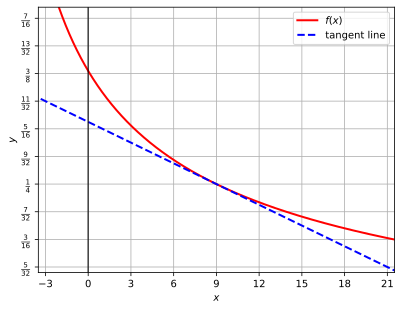

In [16]:
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_format = 'svg'
xs = np.linspace(-4, 22, num=1000)
ys = 1./np.sqrt(7 + xs)
plt.plot(xs, ys, lw=2, c="r", label=r"$f(x)$")
plt.plot(xs, 0.25 + (9 - xs) / 128, lw=2, c="b", ls="--", label="tangent line")
plt.grid()
plt.xlim(-3.5, 21.5)
plt.ylim(0.15, 0.45)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.xticks(np.arange(-3, 22, 3))
plt.yticks(np.linspace(5./32, 7./16, num=10),
           [ r"$\frac{5}{32}$", r"$\frac{3}{16}$", r"$\frac{7}{32}$", r"$\frac{1}{4}$", r"$\frac{9}{32}$", r"$\frac{5}{16}$", r"$\frac{11}{32}$", r"$\frac{3}{8}$", r"$\frac{13}{32}$", r"$\frac{7}{16}$"])
plt.legend()
plt.axvline(c='k', alpha=0.7)
plt.axhline(c='k', alpha=0.7);

## Variant 2

Using the graphs of $y = f(x)$ and $y = a(x-9)$, calculate $\lim\limits_{x\to 9} \frac{f(x)}{x-9}$.

In [19]:
import plotly.graph_objects as go
from functools import reduce

def tangent_slider(slopes):
    fig = go.Figure()
    left = np.linspace(-4, 8, num=241)
    right = np.linspace(10, 22, num=241)
    mid = np.linspace(8, 10, num=2001)
    xs = reduce(np.union1d, [left, mid, right])
    xs_line = np.arange(-4, 23)
    ys = 1./np.sqrt(7 + xs) - 0.25
    fig.add_trace(
        go.Scatter(x=xs, y=ys, name="f(x)", visible=True, line=dict(color='red', width=3))
    )
    for i, slope in enumerate(slopes):
        fig.add_trace(
            go.Scatter(
                x=xs_line,
                y=slope * (xs_line - 9),
                name=f"y = a(x-9)",
                visible=False,
                line=dict(color="blue", width=2),
            )
        )

    fig.update_layout(xaxis_title=r"x",
                      yaxis_title=r"y",
                      margin=dict(t=50),
                      xaxis = dict(tickmode = 'linear', tick0 = -3, dtick = 3),
                      yaxis_range=[-0.1, 0.3])
    
    fig.add_vline(0)
    fig.add_hline(0)
    
    fig.data[1].visible = True

    # Create and add slider
    steps = []
    for i in range(len(slopes)):
        step = dict(
            method="update",
            args=[{"visible": [True,] + [False]*len(slopes)}],  # layout attribute
            label=round(slopes[i], 4)
        )
        step["args"][0]["visible"][i + 1] = True  # Toggle i'th trace to "visible"
        steps.append(step)

    sliders = [dict(
        active=0,
        pad={"t": 50},
        currentvalue={"prefix": r"a="}, 
        steps=steps
    )]
        
    fig.update_layout(
        sliders=sliders,
    )
    fig.show()

In [20]:
left = np.linspace(-0.1, -0.02, num=9)
right = np.linspace(0, 0.1, num=11)
mid = np.linspace(-0.02, 0, num=21)
slopes = reduce(np.union1d, [left, mid, right])

tangent_slider(slopes)

<span style="display:none" id="q_discriminant_calc">W3sicXVlc3Rpb24iOiAiXHUwNDI3XHUwNDM1XHUwNDNjXHUwNDQzIFx1MDQ0MFx1MDQzMFx1MDQzMlx1MDQzNVx1MDQzZCBcdTA0MzRcdTA0MzhcdTA0NDFcdTA0M2FcdTA0NDBcdTA0MzhcdTA0M2NcdTA0MzhcdTA0M2RcdTA0MzBcdTA0M2RcdTA0NDIgXHUwNDNhXHUwNDMyXHUwNDMwXHUwNDM0XHUwNDQwXHUwNDMwXHUwNDQyXHUwNDNkXHUwNDNlXHUwNDMzXHUwNDNlIFx1MDQ0M1x1MDQ0MFx1MDQzMFx1MDQzMlx1MDQzZFx1MDQzNVx1MDQzZFx1MDQzOFx1MDQ0ZiAkM3heMiAtIDV4ICsgMiA9IDAkPyIsICJ0eXBlIjogIm51bWVyaWMiLCAiYW5zd2VycyI6IFt7InR5cGUiOiAidmFsdWUiLCAidmFsdWUiOiAxLCAiY29ycmVjdCI6IHRydWUsICJmZWVkYmFjayI6ICJcdTA0MTJcdTA0MzVcdTA0NDBcdTA0M2RcdTA0M2UhICREID0gKC01KV4yIC0gNFxcY2RvdCAzIFxcY2RvdCAyID0gMjUtMjQgPTEkIn0sIHsidHlwZSI6ICJkZWZhdWx0IiwgImZlZWRiYWNrIjogIlx1MDQxZFx1MDQzNSBcdTA0M2ZcdTA0M2VcdTA0NDVcdTA0M2VcdTA0MzZcdTA0MzUifV19LCB7InF1ZXN0aW9uIjogIlx1MDQyN1x1MDQzNVx1MDQzY1x1MDQ0MyBcdTA0NDBcdTA0MzBcdTA0MzJcdTA0MzVcdTA0M2QgXHUwNDM0XHUwNDM4XHUwNDQxXHUwNDNhXHUwNDQwXHUwNDM4XHUwNDNjXHUwNDM4XHUwNDNkXHUwNDMwXHUwNDNkXHUwNDQyIFx1MDQzYVx1MDQzMlx1MDQzMFx1MDQzNFx1MDQ0MFx1MDQzMFx1MDQ0Mlx1MDQzZFx1MDQzZVx1MDQzM1x1MDQzZSBcdTA0NDNcdTA0NDBcdTA0MzBcdTA0MzJcdTA0M2RcdTA0MzVcdTA0M2RcdTA0MzhcdTA0NGYgJDJ4XjIgKyA2eCArIDcgPSAwJD8iLCAidHlwZSI6ICJudW1lcmljIiwgImFuc3dlcnMiOiBbeyJ0eXBlIjogInZhbHVlIiwgInZhbHVlIjogLTIwLCAiY29ycmVjdCI6IHRydWUsICJmZWVkYmFjayI6ICJcdTA0MTJcdTA0MzVcdTA0NDBcdTA0M2RcdTA0M2UhICREID0gNl4yIC0gNFxcY2RvdCAyIFxcY2RvdCA3ID0gMzYtNTYgPS0yMCQifSwgeyJ0eXBlIjogImRlZmF1bHQiLCAiZmVlZGJhY2siOiAiXHUwNDFkXHUwNDM1IFx1MDQzZlx1MDQzZVx1MDQ0NVx1MDQzZVx1MDQzNlx1MDQzNSJ9XX0sIHsicXVlc3Rpb24iOiAiXHUwNDI3XHUwNDM1XHUwNDNjXHUwNDQzIFx1MDQ0MFx1MDQzMFx1MDQzMlx1MDQzNVx1MDQzZCBcdTA0MzRcdTA0MzhcdTA0NDFcdTA0M2FcdTA0NDBcdTA0MzhcdTA0M2NcdTA0MzhcdTA0M2RcdTA0MzBcdTA0M2RcdTA0NDIgXHUwNDNhXHUwNDMyXHUwNDMwXHUwNDM0XHUwNDQwXHUwNDMwXHUwNDQyXHUwNDNkXHUwNDNlXHUwNDMzXHUwNDNlIFx1MDQ0M1x1MDQ0MFx1MDQzMFx1MDQzMlx1MDQzZFx1MDQzNVx1MDQzZFx1MDQzOFx1MDQ0ZiAkLTl4XjIgKyAxMnggLSA0ID0gMCQ/IiwgInR5cGUiOiAibnVtZXJpYyIsICJhbnN3ZXJzIjogW3sidHlwZSI6ICJ2YWx1ZSIsICJ2YWx1ZSI6IDAsICJjb3JyZWN0IjogdHJ1ZSwgImZlZWRiYWNrIjogIlx1MDQxMlx1MDQzNVx1MDQ0MFx1MDQzZFx1MDQzZSEgJEQgPSAxMl4yIC0gNFxcY2RvdCAoLTkpIFxcY2RvdCAoLTQpID0gMTQ0LTE0NCA9MCQifSwgeyJ0eXBlIjogImRlZmF1bHQiLCAiZmVlZGJhY2siOiAiXHUwNDFkXHUwNDM1IFx1MDQzZlx1MDQzZVx1MDQ0NVx1MDQzZVx1MDQzNlx1MDQzNSJ9XX1d</span>

In [1]:
# from jupyterquiz import display_quiz
# display_quiz("#q_discriminant_calc", question_alignment="center", num=1)

<!--
По дискриминанту легко определить количество **действительных** корней квадратного уравнения. А именно, уравнение {eq}`quadratic-eq` 

* имеет два корня, если $D > 0$;
* имеет один корень, если $D = 0$;
* не имеет действительных корней, если $D < 0$.
-->